<a href="https://colab.research.google.com/github/sgl13/Machine_Learning/blob/main/Decision_tree_Classsification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Test case:- from the given data wbc.csv we need to predict the presence of cancer.or not
information about the data?
--
this csv file contain test reports on differant white blood cells based on that tests we need to predict cancer is presence or not

to built the ml model to predict the cancer

**Step 1 import necessary libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/wbc.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**EDA**

In [6]:
#check the number of rows and columns
df.shape

(569, 32)

In [7]:
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [8]:
#get the descriptive stats
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
#check the columns
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

**from the above command i can see 2 columns are unrelated columns**

1.id:- we are nothing to do with patient id means wont we  apply any arithamatic operations so i am dropping the column
2.unnamed:32:- column all are null values in the column so drop the column

In [10]:
#check the null values
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [11]:
#check the duplicate
df.duplicated().sum()

np.int64(0)

In [12]:
#drop the related columns
df.drop(columns="id",inplace=True)
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:

#what is the target variable from wbc.csv?
# diagnosis is the target variable
# it is classification variable
# we need to predict categories
# check how many unique values in the columns diagnosis
df['diagnosis'].unique()
#there are 2 categories if is a binary classification data
# we need to predict M-->malign and b--> benign


array(['M', 'B'], dtype=object)

In [15]:
#check the distribution of values in the diagnosis
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


**define feature and target**

In [16]:
x = df.loc[:,df.columns[1:]]
x.head()
y = df['diagnosis']
#in the column diagnosis "m" and "b" are categorical data convert into numbers
#replace m with 1 and b with 0
# to replace the data in pandas dataframe we use map()
y = y.map({"M":1,"B":0}) #one hot coding

In [17]:
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


**split the data**

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=1000)

**Scale the data**

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

**2nd jar:- supervised learning task**

---
3rd model jar:- binary tree calssification
 to ask the right question use the entropy-->caluclate randomness

In [20]:
from sklearn.tree import DecisionTreeClassifier
#initialize
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train) # loss automatically caluclated-> reduction in entropy
# predict on the test data
y_pred = dt.predict(x_test)
y_pred


array([1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0])

**evaluate**

In [21]:
from sklearn.metrics import accuracy_score,f1_score
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(acc)
print(f1)

0.916083916083916
0.896551724137931


**5th leaning jar: when we need to find the max_depth by using the hit and trail method**

In [22]:
from sklearn.model_selection import cross_val_score
for depth in [1,2,3,4,5,6,7,8,9,10,20,30]:
  dt = DecisionTreeClassifier(max_depth=depth)
  dt.fit(x_train,y_train)
  train_accuracy = dt.score(x_train,y_train)
  val_accuracy = cross_val_score(dt,x_train,y_train,cv=10)
  print("depth: ",depth,"Training accuracy: ",train_accuracy,"cross_val_score",np.mean(val_accuracy))

depth:  1 Training accuracy:  0.9366197183098591 cross_val_score 0.9293466223698781
depth:  2 Training accuracy:  0.9530516431924883 cross_val_score 0.9340531561461795
depth:  3 Training accuracy:  0.9812206572769953 cross_val_score 0.9388150609080842
depth:  4 Training accuracy:  0.9882629107981221 cross_val_score 0.9552602436323367
depth:  5 Training accuracy:  0.9953051643192489 cross_val_score 0.9576411960132891
depth:  6 Training accuracy:  0.9976525821596244 cross_val_score 0.9553156146179402
depth:  7 Training accuracy:  1.0 cross_val_score 0.9457918050941307
depth:  8 Training accuracy:  1.0 cross_val_score 0.9529346622369879
depth:  9 Training accuracy:  1.0 cross_val_score 0.9481727574750831
depth:  10 Training accuracy:  1.0 cross_val_score 0.9529346622369879
depth:  20 Training accuracy:  1.0 cross_val_score 0.9363233665559247
depth:  30 Training accuracy:  1.0 cross_val_score 0.9482281284606866


**best max depth get 5**

In [23]:
# again train the model by using max depth
# also it helps to reduce the overfitting
from sklearn.tree import DecisionTreeClassifier
#initialize
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(x_train,y_train) # loss automatically caluclated-> reduction in entropy
# predict on the test data
y_pred = dt.predict(x_test)
y_pred

array([1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0])

In [24]:
from sklearn.metrics import accuracy_score,f1_score
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(acc)
print(f1)

0.9300699300699301
0.9137931034482759


**feature importance**

In [25]:
# 31 columns
df.shape

(569, 31)

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=7)

In [27]:
from sklearn.tree import DecisionTreeClassifier # gini work similar to gradient decent
dt = DecisionTreeClassifier(criterion="gini",max_depth=5)
dt.fit(x_train,y_train)
importence = dt.feature_importances_ #actual decision takes in future importance
list(zip(importence,x_test.columns)) # explicit value in test columns


[(np.float64(0.0), 'radius_mean'),
 (np.float64(0.046359823061412425), 'texture_mean'),
 (np.float64(0.0), 'perimeter_mean'),
 (np.float64(0.0), 'area_mean'),
 (np.float64(0.0), 'smoothness_mean'),
 (np.float64(0.0), 'compactness_mean'),
 (np.float64(0.0), 'concavity_mean'),
 (np.float64(0.0747569857936474), 'concave points_mean'),
 (np.float64(0.0), 'symmetry_mean'),
 (np.float64(0.0013190035744923404), 'fractal_dimension_mean'),
 (np.float64(0.0), 'radius_se'),
 (np.float64(0.0), 'texture_se'),
 (np.float64(0.009921469271266626), 'perimeter_se'),
 (np.float64(0.0), 'area_se'),
 (np.float64(0.0), 'smoothness_se'),
 (np.float64(0.0), 'compactness_se'),
 (np.float64(0.005066527098028595), 'concavity_se'),
 (np.float64(0.028580409270930533), 'concave points_se'),
 (np.float64(0.008444211830047657), 'symmetry_se'),
 (np.float64(0.009794856849408513), 'fractal_dimension_se'),
 (np.float64(0.0), 'radius_worst'),
 (np.float64(0.015199581294085785), 'texture_worst'),
 (np.float64(0.7360816016

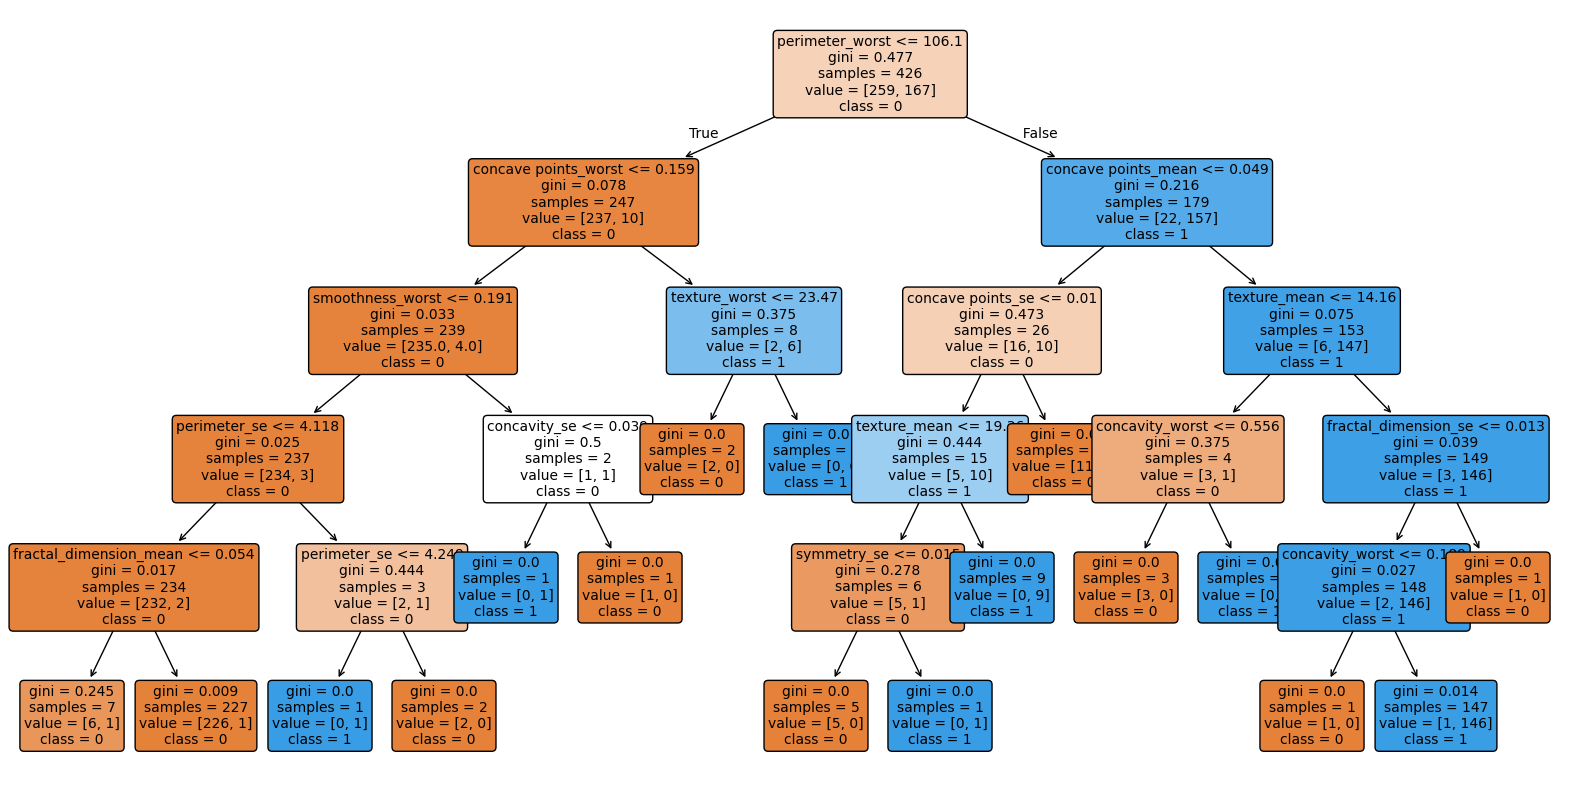

In [28]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt,filled=True,rounded=True,feature_names=x.columns,class_names=dt.classes_.astype(str),fontsize=10)
#gini measure randomness or impurity
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

print("--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

print("\n--- KNN Performance (k=5) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

--- Logistic Regression Performance ---
Accuracy: 0.9440559440559441
F1 Score: 0.9047619047619048

--- KNN Performance (k=5) ---
Accuracy: 0.9440559440559441
F1 Score: 0.9090909090909091


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
